# Comparative Metrics Analysis — Real Data

Loads all 9 metrics CSVs (variables: `pr`, `tmin`, `tmax`; models: `OLS`, `Ano`, `AnoVar`).  
Compares model performance via boxplots across 100 Monte Carlo configurations.  
Obs reference metrics (`interday`, `acf_lag1`) computed **once** on all stations, eval period days 365:730.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
def interday_variability(arr):
    """Mean absolute day-to-day difference, averaged over stations."""
    A = np.asarray(arr, dtype=float)
    return float(np.nanmean(np.nanmean(np.abs(np.diff(A, axis=0)), axis=1)))


def mean_acf_lag1(arr):
    """ACF at lag 1 averaged over stations."""
    A = np.asarray(arr, dtype=float)
    acf_vals = []
    for s in range(A.shape[1]):
        x = A[:, s]
        mask = np.isfinite(x)
        if mask.sum() < 3:
            continue
        x = x[mask]
        x_c = x - x.mean()
        var = np.mean(x_c ** 2)
        if var < 1e-12:
            continue
        acf_vals.append(float(np.mean(x_c[:-1] * x_c[1:]) / var))
    return float(np.nanmean(acf_vals)) if acf_vals else np.nan

In [3]:
METRICS_DIR = "/home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/Validation_real_data/"

variables = ['pr', 'tmin', 'tmax']
models    = ['ols', 'ano', 'anovar']

dfs = []
for var in variables:
    for model in models:
        path = os.path.join(METRICS_DIR, f"metrics_{var}_{model}.csv")
        df = pd.read_csv(path)
        df['variable'] = var
        df['model']    = model
        dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
print(f"Total rows: {len(df_all)}")
print(df_all.groupby(['variable', 'model'])[['rmse_s', 'ssim', 'interday_mod', 'acf_lag1_mod']].median().round(4))

Total rows: 900
                 rmse_s    ssim  interday_mod  acf_lag1_mod
variable model                                             
pr       ano     2.7840  0.6412        4.2491        0.0548
         anovar  2.6393  0.6256        3.1679        0.1270
         ols     2.9252  0.6444        4.3536        0.0553
tmax     ano     1.8782  0.9865        3.7412        0.9312
         anovar  1.8695  0.9869        3.4706        0.9407
         ols     1.8755  0.9867        3.7447        0.9322
tmin     ano     2.5945  0.5715        3.9340        0.8867
         anovar  2.5782  0.5718        3.8170        0.8928
         ols     2.6676  0.5746        3.8910        0.8876


In [4]:
OBS_DIR    = "/home/vihoua@labos.polymtl.ca/Projet_1/Validation_OBS/Data_clean/"
EVAL_SLICE = slice(365, 730)

obs_pr_raw   = pd.read_csv(OBS_DIR + "data_precip_2yr_clean.csv",  index_col=0).values.astype(float)
obs_tmin_raw = pd.read_csv(OBS_DIR + "data_tmin_2yr_clean.csv",    index_col=0).values.astype(float)
obs_tmax_raw = pd.read_csv(OBS_DIR + "data_tmax_2yr_clean.csv",    index_col=0).values.astype(float)

# Precip: dry-day threshold (same as in Monte Carlo notebooks)
obs_pr = obs_pr_raw.copy()
obs_pr[obs_pr < 0.5] = 0

# Eval period, all stations
obs_pr_eval   = obs_pr[EVAL_SLICE]
obs_tmin_eval = obs_tmin_raw[EVAL_SLICE]
obs_tmax_eval = obs_tmax_raw[EVAL_SLICE]

# Compute once on full station set
interday_obs = {
    'pr':   interday_variability(obs_pr_eval),
    'tmin': interday_variability(obs_tmin_eval),
    'tmax': interday_variability(obs_tmax_eval),
}
acf_lag1_obs = {
    'pr':   mean_acf_lag1(obs_pr_eval),
    'tmin': mean_acf_lag1(obs_tmin_eval),
    'tmax': mean_acf_lag1(obs_tmax_eval),
}

print("Obs reference metrics (all stations, days 365:730):")
for var in variables:
    print(f"  {var:>4}:  interday = {interday_obs[var]:.4f}   acf_lag1 = {acf_lag1_obs[var]:.4f}")

Obs reference metrics (all stations, days 365:730):
    pr:  interday = 4.1478   acf_lag1 = 0.0513
  tmin:  interday = 3.8506   acf_lag1 = 0.8889
  tmax:  interday = 3.7146   acf_lag1 = 0.9331


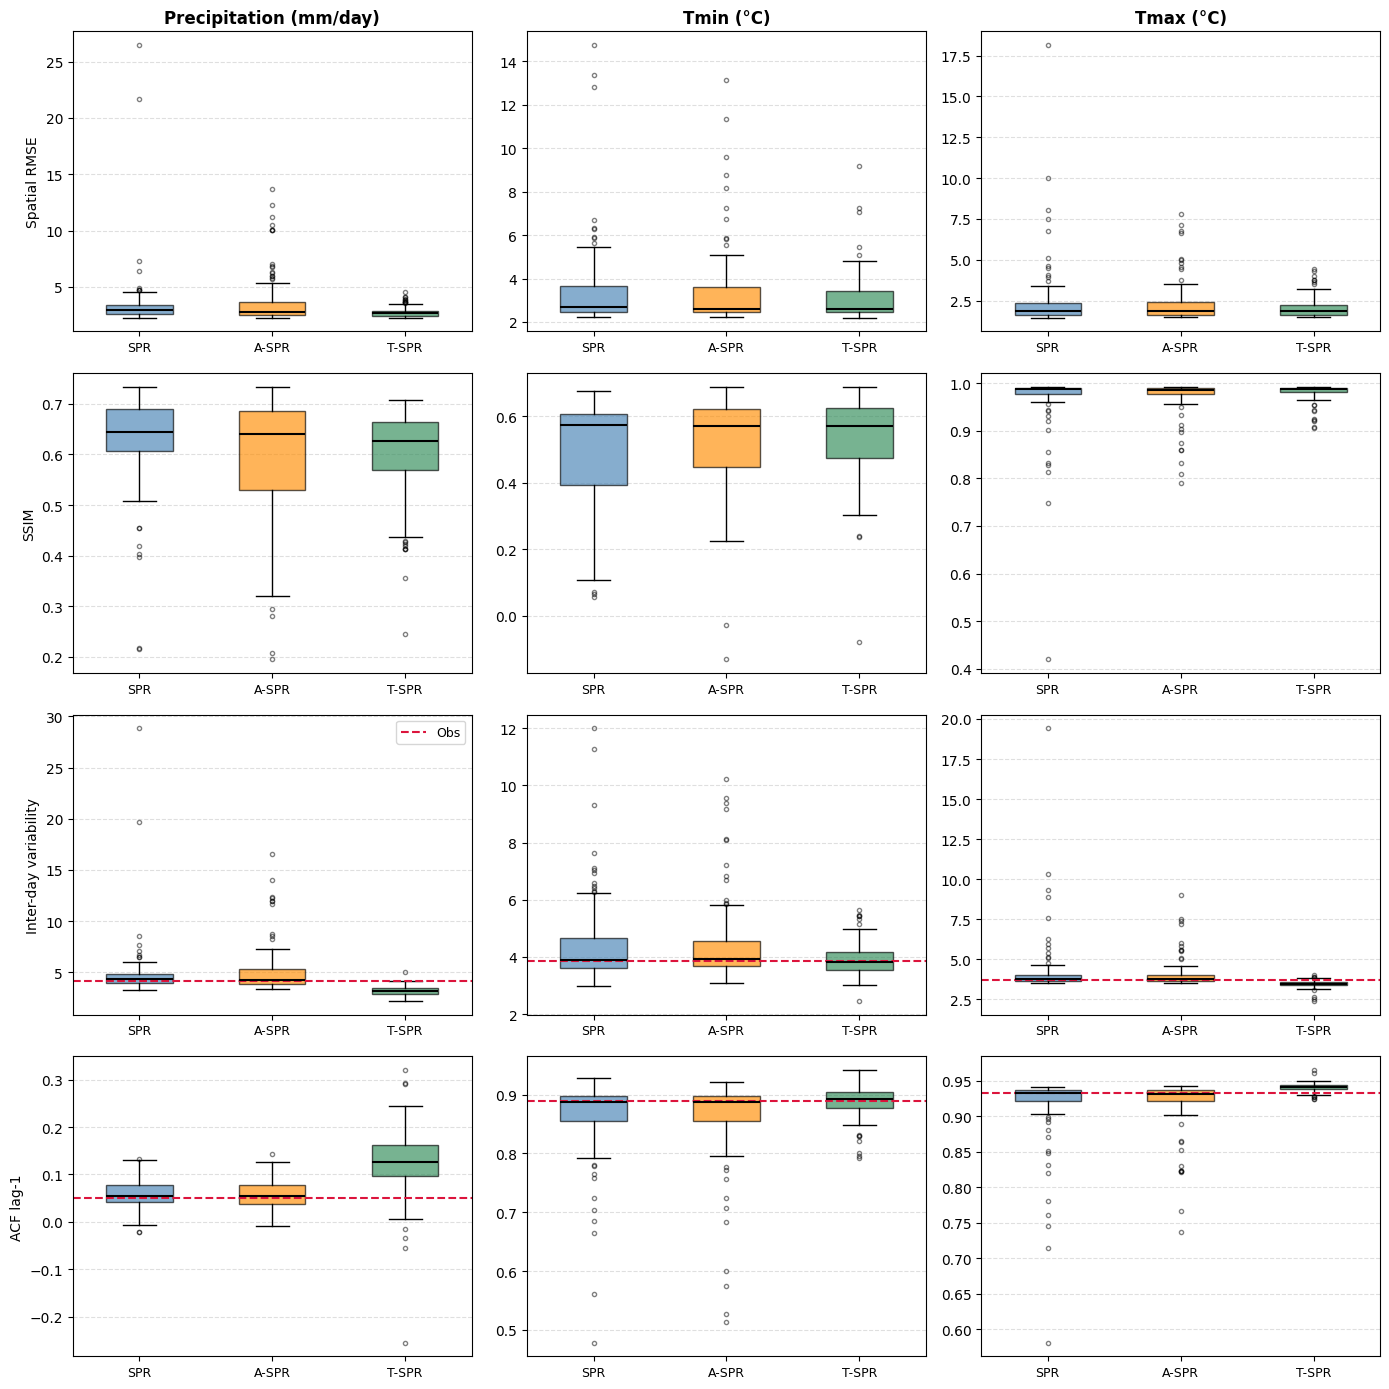

Figure saved.


In [5]:
MODEL_LABELS = {'ols': 'SPR', 'ano': 'A-SPR', 'anovar': 'T-SPR'}
MODEL_COLORS = {'ols': 'steelblue', 'ano': 'darkorange', 'anovar': 'seagreen'}
VAR_TITLES   = {'pr': 'Precipitation (mm/day)', 'tmin': 'Tmin (°C)', 'tmax': 'Tmax (°C)'}

METRIC_ROWS = [
    ('rmse_s',       'Spatial RMSE',          None),
    ('ssim',         'SSIM',                  None),
    ('interday_mod', 'Inter-day variability',  interday_obs),
    ('acf_lag1_mod', 'ACF lag-1',              acf_lag1_obs),
]

fig, axes = plt.subplots(4, 3, figsize=(14, 14))

for row, (metric, ylabel, obs_ref) in enumerate(METRIC_ROWS):
    for col, var in enumerate(variables):
        ax = axes[row, col]

        data_to_plot = [
            df_all[(df_all['variable'] == var) & (df_all['model'] == m)][metric].dropna().values
            for m in models
        ]

        bp = ax.boxplot(
            data_to_plot,
            positions=[1, 2, 3],
            widths=0.5,
            patch_artist=True,
            medianprops=dict(color='black', linewidth=1.5),
            flierprops=dict(marker='o', markersize=3, alpha=0.5),
        )
        for patch, m in zip(bp['boxes'], models):
            patch.set_facecolor(MODEL_COLORS[m])
            patch.set_alpha(0.65)

        if obs_ref is not None:
            show_label = (row == 2 and col == 0)
            ax.axhline(
                obs_ref[var],
                color='crimson', linestyle='--', linewidth=1.5,
                label='Obs' if show_label else '_nolegend_'
            )
            if show_label:
                ax.legend(fontsize=9)

        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels([MODEL_LABELS[m] for m in models], fontsize=9)
        ax.grid(axis='y', linestyle='--', alpha=0.4)

        if row == 0:
            ax.set_title(VAR_TITLES[var], fontsize=12, fontweight='bold')
        if col == 0:
            ax.set_ylabel(ylabel, fontsize=10)

# plt.suptitle(
#     "Comparative metrics — SPR vs A-SPR vs T-SPR\n"
#     "100 Monte Carlo configurations, 3 training stations, K=2",
#     fontsize=13, y=1.01
# )
plt.tight_layout()
plt.savefig(METRICS_DIR + "comparative_metrics_REAL.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

Generating real-data metric comparison plots (one per variable, per metric)


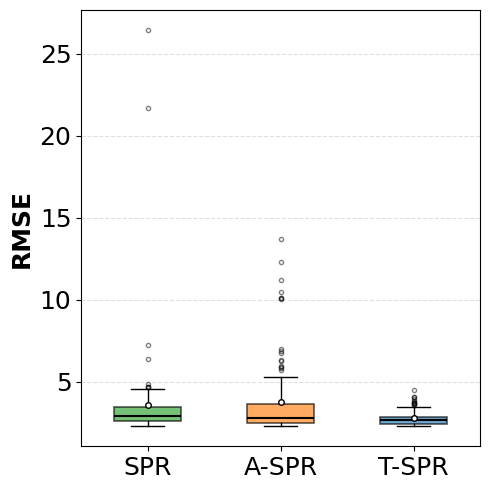

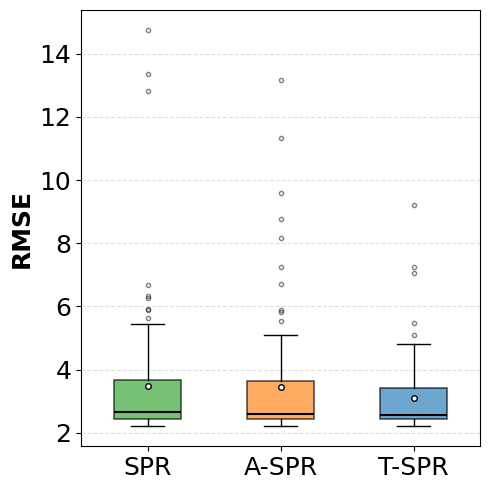

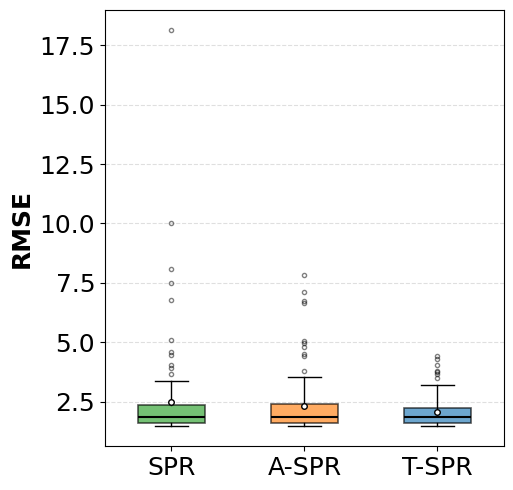

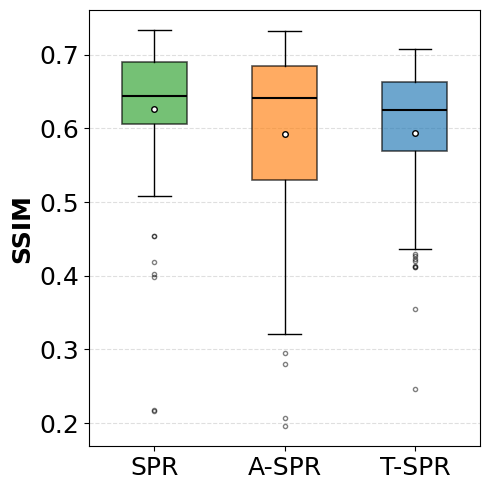

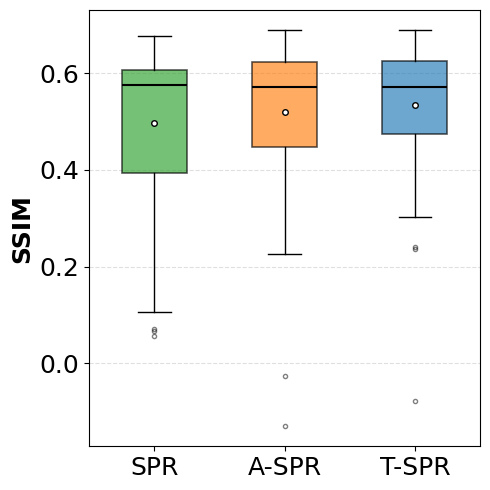

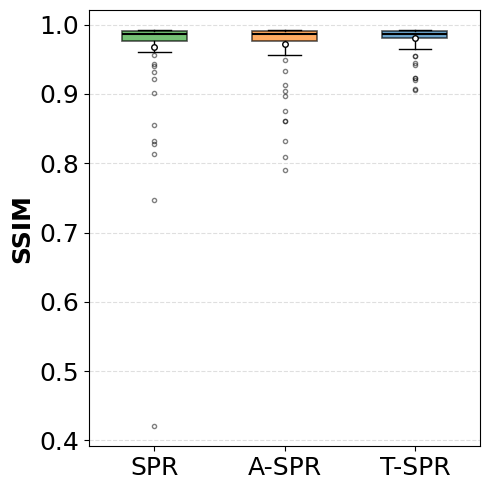

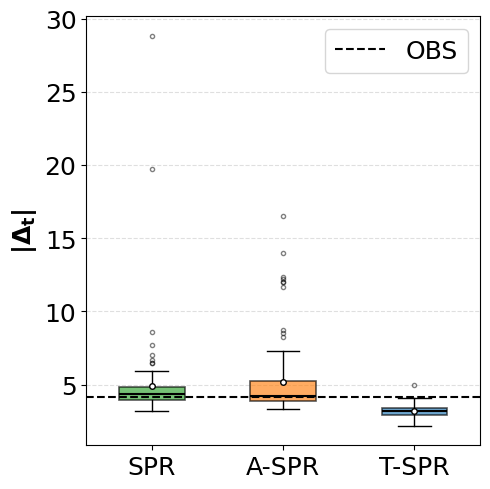

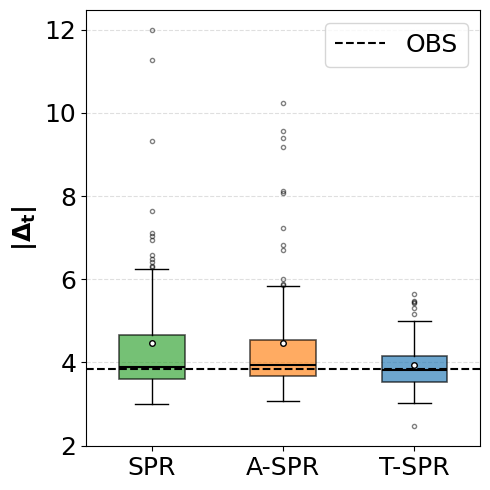

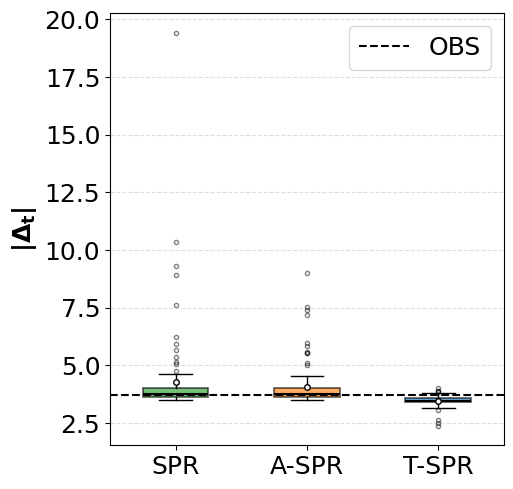

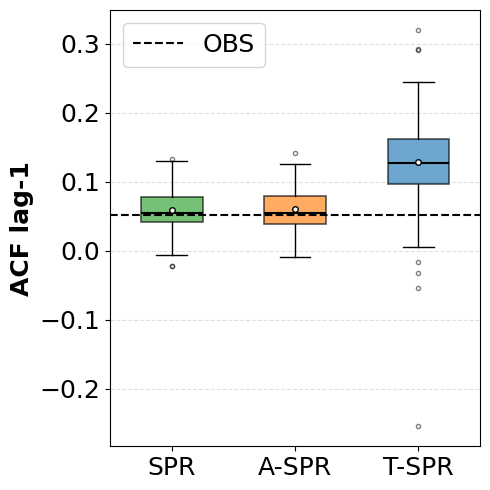

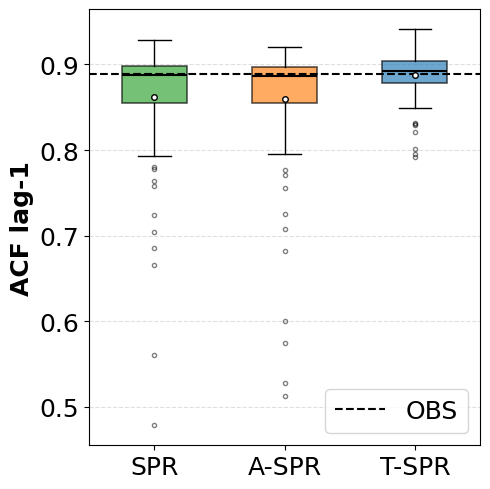

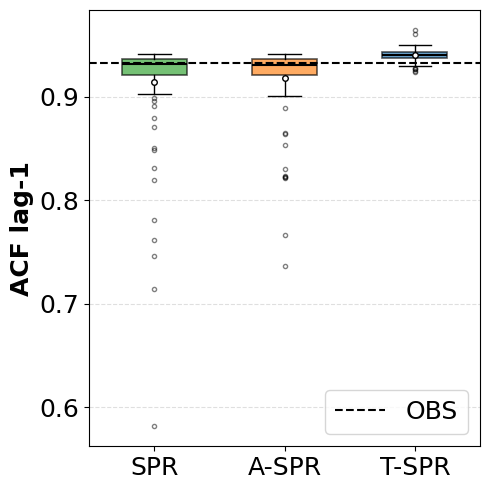


Total figures generated: 12


In [6]:
MODEL_LABELS = {'ols': 'SPR', 'ano': 'A-SPR', 'anovar': 'T-SPR'}
MODEL_COLORS = {'ols': '#2ca02c', 'ano': '#ff7f0e', 'anovar': '#1f77b4'}
VAR_TITLES   = {'pr': 'Precipitation (mm/day)', 'tmin': 'Tmin (°C)', 'tmax': 'Tmax (°C)'}

METRIC_ROWS = [
    ('rmse_s',       'RMSE',          None),
    ('ssim',         'SSIM',                  None),
    ('interday_mod', r'$\mathbf{|\Delta_t|}$', interday_obs),
    ('acf_lag1_mod', 'ACF lag-1',             acf_lag1_obs),
]


def plot_real_metric_comparison(df_all, var, metric, ylabel, obs_ref=None):
    """
    Plot boxplot comparison for a single (variable, metric) combination.
    Shows SPR vs A-SPR vs T-SPR with filled colored boxes
    and optional observation reference line.
    """
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    data_to_plot = [
        df_all[(df_all['variable'] == var) & (df_all['model'] == m)][metric].dropna().values
        for m in models
    ]

    bp = ax.boxplot(
        data_to_plot,
        positions=[1, 2, 3],
        widths=0.5,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1.5),
        flierprops=dict(marker='o', markersize=3, alpha=0.5),
        showmeans=True,
        meanprops=dict(marker='.', markerfacecolor='white', markeredgecolor='black', markersize=8),
    )

    # Fill each box with method-specific color
    for i, m in enumerate(models):
        c = MODEL_COLORS[m]
        bp['boxes'][i].set_facecolor(c)
        bp['boxes'][i].set_alpha(0.65)
        bp['boxes'][i].set_edgecolor('black')
        bp['boxes'][i].set_linewidth(1.2)

    # Observation reference line if applicable
    if obs_ref is not None:
        ax.axhline(
            obs_ref[var],
            color='black', linestyle='--', linewidth=1.5,
            label='OBS'
        )
        ax.legend(fontsize=18, loc='best')

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels([MODEL_LABELS[m] for m in models], fontsize=18)
    ax.tick_params(axis='y', labelsize=18)
    ax.set_ylabel(ylabel, fontsize=18, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    return fig


# --- Generate one figure per (variable, metric) ---
print("=" * 60)
print("Generating real-data metric comparison plots (one per variable, per metric)")
print("=" * 60)

real_figures = {}

for metric, ylabel, obs_ref in METRIC_ROWS:
    for var in variables:
        fig = plot_real_metric_comparison(df_all, var, metric, ylabel, obs_ref)
        key = f"{metric}_{var}"
        real_figures[key] = fig
        plt.show()

print(f"\nTotal figures generated: {len(real_figures)}")

In [7]:
# --- Save all figures to disk ---
print("=" * 60)
print("Saving real-data metric comparison plots")
print("=" * 60)

for key, fig in real_figures.items():
    fname = f"{METRICS_DIR}real_{key}.png"
    fig.savefig(fname, dpi=600, bbox_inches='tight')
    print(f"Saved: {fname}")

print(f"\nTotal figures saved: {len(real_figures)}")

Saving real-data metric comparison plots
Saved: /home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/Validation_real_data/real_rmse_s_pr.png
Saved: /home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/Validation_real_data/real_rmse_s_tmin.png
Saved: /home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/Validation_real_data/real_rmse_s_tmax.png
Saved: /home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/Validation_real_data/real_ssim_pr.png
Saved: /home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/Validation_real_data/real_ssim_tmin.png
Saved: /home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/Validation_real_data/real_ssim_tmax.png
Saved: /home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/Validation_real_data/real_interday_mod_pr.png
Saved: /home/vihoua@labos.polymtl.ca/Projet_2/Interpolation/Interp_A1/Simulations/Validation_real